<a href="https://colab.research.google.com/github/danielduartes/Atividade-de-Machine-Learning-Regressao/blob/main/NotebookRegressao.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Os datasets são:
#### Ao escolher o dataset que você vai trabalhar, copie o path e cole na célula de abetura do arquivo para ter acesso ao dataframe.

*   **Real State Valuation Dataset** — Dataset de Taiwan sobre preços de imóveis, com colunas como distância até estação de metrô, número de lojas de conveniência próximas, latitude, longitude e idade do imóvel — todas numéricas, target também numérico (preço por área).
https://www.kaggle.com/datasets/yasserh/titanic-dataset

*   **Calculate Concrete Strength** — Dataset sobre resistência de concreto, com colunas como quantidade de cimento, água, agregados, idade da mistura — tudo numérico, prevendo a resistência à compressão (target numérico).
https://www.kaggle.com/datasets/uciml/mushroom-classification


zczxczxczcxz

In [ ]:
# Importar bibliotecas necessárias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import sklearn
warnings.filterwarnings('ignore')

# Bibliotecas de Machine Learning
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

# Configurar estilo para melhores visualizações
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

print("Todas as bibliotecas importadas com sucesso!")
print("Versão do Scikit-learn:", sklearn.__version__)


Todas as bibliotecas importadas com sucesso!
Versão do Scikit-learn: 1.6.1


In [ ]:
# Carregue seu dataset aqui
# Coloque o caminho do arquivo CSV que você baixou do Kaggle entre as aspas abaixo
df = pd.read_csv("")  # TODO: coloque o path do seu arquivo CSV aqui

# Separe suas features (X) e seu target (y)
# X = todas as colunas que serão usadas para prever (menos a coluna target)
# y = a coluna que você quer prever (deve ser numérica, já que é regressão)

X = df.drop(columns=[''])  # TODO: coloque o nome da(s) coluna(s) que NÃO serão usadas como feature (ex: 'preco')
y = df['']  # TODO: coloque o nome da coluna que será o seu target (ex: 'preco')

print("Dataset carregado com sucesso!")
print(f"Formato do dataset: {X.shape}")
print(f"Número de amostras: {X.shape[0]}")
print(f"Número de features: {X.shape[1]}")
print(f"Faixa da variável target: {y.min():.2f} - {y.max():.2f}")
print(f"Valor médio do target: {y.mean():.2f}")

Dataset carregado com sucesso!
Formato do dataset: (20640, 8)
Número de amostras: 20640
Número de features: 8
Faixa da variável target: $0.15 - $5.00 (centenas de milhares)
Preço médio das casas: $2.07 centenas de milhares


In [ ]:
# Exibir informações básicas sobre nosso dataset
print("=== VISÃO GERAL DO DATASET ===")
print(f"Formato do dataset: {X.shape}")
print(f"Formato do target: {y.shape}")
print("\n=== PRIMEIRAS 5 LINHAS ===")
print(X.head())


=== VISÃO GERAL DO DATASET ===
Formato do dataset: (20640, 8)
Formato do target: (20640,)

=== PRIMEIRAS 5 LINHAS ===
   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  
0    -122.23  
1    -122.22  
2    -122.24  
3    -122.25  
4    -122.25  


In [ ]:
  print("\n=== RESUMO ESTATÍSTICO ===")
  X.describe()


=== RESUMO ESTATÍSTICO ===


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000


In [ ]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   MedInc      20640 non-null  float64
 1   HouseAge    20640 non-null  float64
 2   AveRooms    20640 non-null  float64
 3   AveBedrms   20640 non-null  float64
 4   Population  20640 non-null  float64
 5   AveOccup    20640 non-null  float64
 6   Latitude    20640 non-null  float64
 7   Longitude   20640 non-null  float64
dtypes: float64(8)
memory usage: 1.3 MB


In [ ]:
print(f"\nValores ausentes nas features: ")
X.isnull().sum().sum()
print(f"Valores ausentes no target: {pd.isnull(y).sum()}")


Valores ausentes nas features: 
Valores ausentes no target: 0


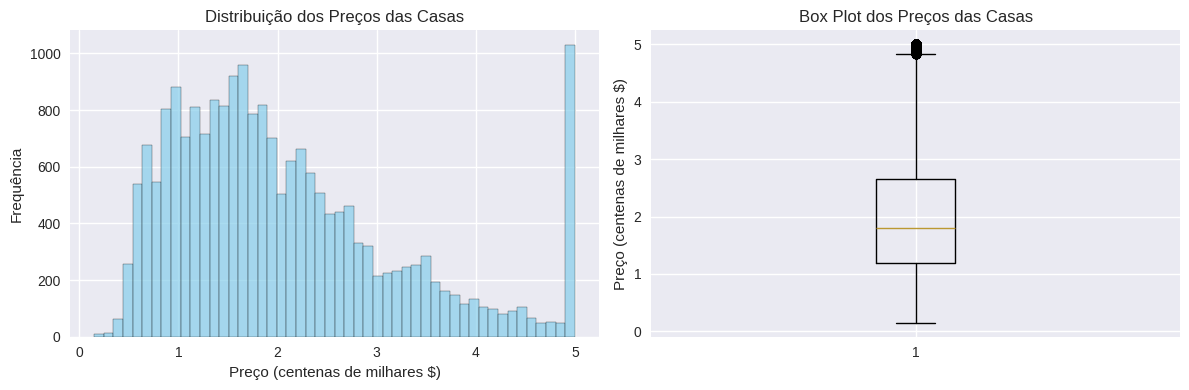

Estatísticas da variável target:
Média: $2.07 centenas de milhares
Mediana: $1.80 centenas de milhares
Desvio padrão: $1.15 centenas de milhares


In [ ]:
# TODO: defina o nome do que você está prevendo e a unidade de medida (se houver)
nome_target = ""  # ex: "Preço da Casa", "Nota do Aluno", "Temperatura"
unidade_target = ""  # ex: "milhares de dólares", "pontos", "°C" (deixe "" se não houver unidade)

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.hist(y, bins=50, alpha=0.7, color='skyblue', edgecolor='black')
plt.title(f'Distribuição de {nome_target}')
plt.xlabel(f'{nome_target} ({unidade_target})' if unidade_target else nome_target)
plt.ylabel('Frequência')

plt.subplot(1, 2, 2)
plt.boxplot(y, vert=True)
plt.title(f'Box Plot de {nome_target}')
plt.ylabel(f'{nome_target} ({unidade_target})' if unidade_target else nome_target)

plt.tight_layout()
plt.show()

print(f"Estatísticas da variável target:")
print(f"Média: {y.mean():.2f} {unidade_target}")
print(f"Mediana: {np.median(y):.2f} {unidade_target}")
print(f"Desvio padrão: {y.std():.2f} {unidade_target}")

=== FEATURES (X) ===
Formato das features: (20640, 8)
Nomes das features: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']
Tipos das features: [dtype('float64')]

=== TARGET (y) ===
Formato do target: (20640,)
Tipo do target: <class 'numpy.ndarray'>
Target é o que queremos prever: Preços das casas


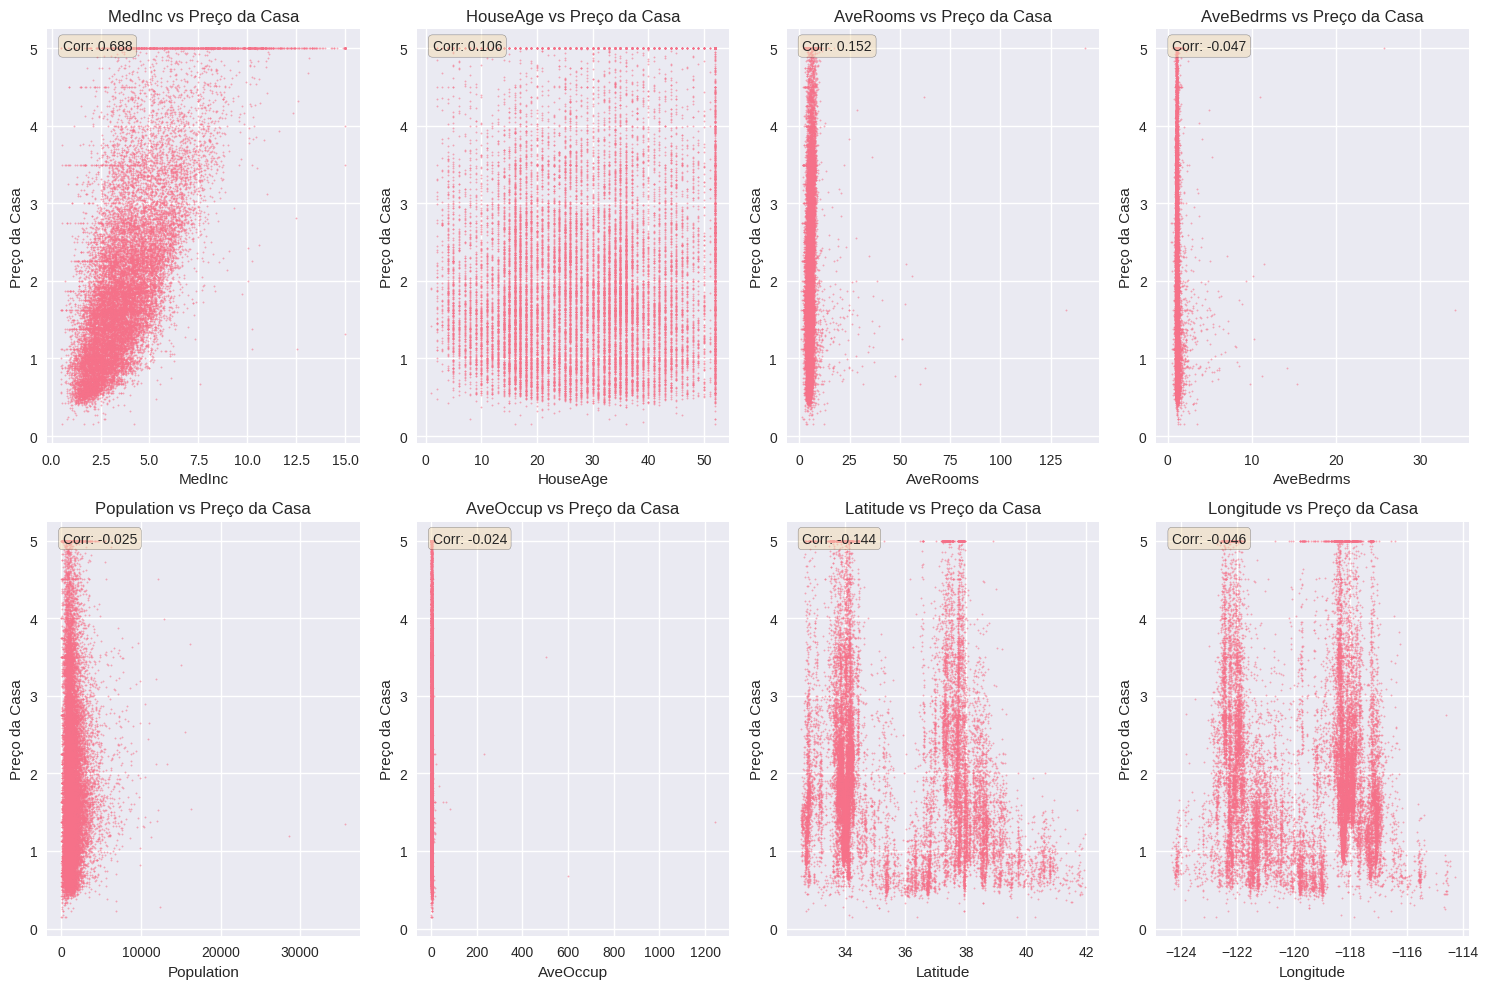

In [ ]:
# Já separamos nossas variáveis, mas vamos confirmar e visualizar a relação
print("=== FEATURES (X) ===")
print(f"Formato das features: {X.shape}")
print(f"Nomes das features: {list(X.columns)}")
print(f"Tipos das features: {X.dtypes.unique()}")

print("\n=== TARGET (y) ===")
print(f"Formato do target: {y.shape}")
print(f"Tipo do target: {type(y)}")
print(f"Target é o que queremos prever: Preços das casas")

# Vamos ver a correlação entre features e target
plt.figure(figsize=(15, 10))
n_features = len(X.columns)
n_cols = 4
n_rows = -(-n_features // n_cols)  # arredonda pra cima

for i, column in enumerate(X.columns):
    plt.subplot(n_rows, n_cols, i+1)
    plt.scatter(X[column], y, alpha=0.5, s=1)
    plt.xlabel(column)
    plt.ylabel('Target')
    plt.title(f'{column} vs Target')

    correlation = X[column].corr(pd.Series(y))
    plt.text(0.05, 0.95, f'Corr: {correlation:.3f}',
             transform=plt.gca().transAxes, bbox=dict(boxstyle="round", facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.show()


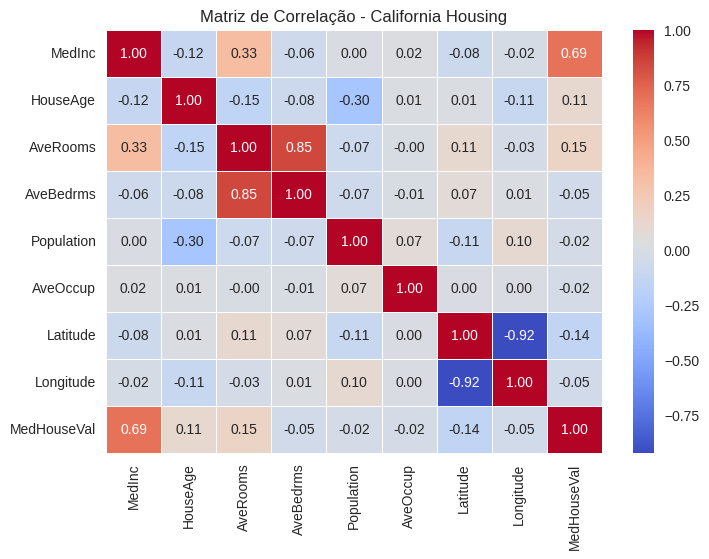

In [ ]:
# unimos X e y em um único DataFrame para o cálculo
# Usamos pd.concat para colocar a coluna do target ao lado das outras features
df_para_corr = pd.concat([X, pd.Series(y, name='target')], axis=1)

# matriz de correlação usando o Pandas
matriz_corr = df_para_corr.corr()

# visualizamos com o Seaborn (Heatmap)
sns.heatmap(matriz_corr, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)

plt.title('Matriz de Correlação')
plt.show()

In [ ]:
# Dividir os dados em conjuntos de treino e teste
# test_size=0.2 significa 20% para teste, 80% para treino
# random_state=42 garante resultados reproduzíveis (mesma divisão sempre)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print("=== RESULTADOS DA DIVISÃO DOS DADOS ===")
print(f"Tamanho do dataset original: {X.shape[0]} amostras")
print(f"Tamanho do conjunto de treino: {X_train.shape[0]} amostras ({X_train.shape[0]/X.shape[0]*100:.1f}%)")
print(f"Tamanho do conjunto de teste: {X_test.shape[0]} amostras ({X_test.shape[0]/X.shape[0]*100:.1f}%)")

print(f"\nFormato das features de treino: {X_train.shape}")
print(f"Formato do target de treino: {y_train.shape}")
print(f"Formato das features de teste: {X_test.shape}")
print(f"Formato do target de teste: {y_test.shape}")

print(f"\nEstatísticas do target do conjunto de treino:")
print(f"Média: ${y_train.mean():.2f}, Desvio: ${y_train.std():.2f}")
print(f"Estatísticas do target do conjunto de teste:")
print(f"Média: ${y_test.mean():.2f}, Desvio: ${y_test.std():.2f}")
print("✓ Ambos conjuntos têm distribuições similares - boa divisão!")


=== RESULTADOS DA DIVISÃO DOS DADOS ===
Tamanho do dataset original: 20640 amostras
Tamanho do conjunto de treino: 16512 amostras (80.0%)
Tamanho do conjunto de teste: 4128 amostras (20.0%)

Formato das features de treino: (16512, 8)
Formato do target de treino: (16512,)
Formato das features de teste: (4128, 8)
Formato do target de teste: (4128,)

Estatísticas do target do conjunto de treino:
Média: $2.07, Desvio: $1.16
Estatísticas do target do conjunto de teste:
Média: $2.06, Desvio: $1.14
✓ Ambos conjuntos têm distribuições similares - boa divisão!


In [ ]:
# Antes do escalonamento - vamos ver as distribuições originais das features
print("=== ANTES DO ESCALONAMENTO ===")
print("Estatísticas das features do conjunto de treino:")
print(X_train.describe())

# Criar uma instância do StandardScaler
scaler = StandardScaler()

# IMPORTANTE: Ajustar o scaler APENAS nos dados de treino
# Isso previne vazamento de dados do conjunto de teste
scaler.fit(X_train)

# Transformar ambos os conjuntos (treino e teste) usando o scaler ajustado
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Converter de volta para DataFrame para manipulação mais fácil
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns, index=X_test.index)

print("\n=== APÓS O ESCALONAMENTO ===")
print("Estatísticas das features escalonadas do conjunto de treino:")
print(X_train_scaled.describe())

print(f"\n✓ Todas as features agora têm média ≈ 0 e desvio ≈ 1")
print(f"✓ Scaler foi ajustado apenas nos dados de treino")
print(f"✓ Mesma transformação aplicada em ambos os conjuntos (treino e teste)")


=== ANTES DO ESCALONAMENTO ===
Estatísticas das features do conjunto de treino:
             MedInc      HouseAge      AveRooms     AveBedrms    Population  \
count  16512.000000  16512.000000  16512.000000  16512.000000  16512.000000   
mean       3.880754     28.608285      5.435235      1.096685   1426.453004   
std        1.904294     12.602499      2.387375      0.433215   1137.056380   
min        0.499900      1.000000      0.888889      0.333333      3.000000   
25%        2.566700     18.000000      4.452055      1.006508    789.000000   
50%        3.545800     29.000000      5.235874      1.049286   1167.000000   
75%        4.773175     37.000000      6.061037      1.100348   1726.000000   
max       15.000100     52.000000    141.909091     25.636364  35682.000000   

           AveOccup      Latitude     Longitude  
count  16512.000000  16512.000000  16512.000000  
mean       3.096961     35.643149   -119.582290  
std       11.578744      2.136665      2.005654  
min     

In [ ]:
# Criar um modelo de Regressão Linear
model = LinearRegression()

print("=== TREINAMENTO DO MODELO ===")
print(f"Modelo criado: {model}")
print(f"Treinando com {X_train_scaled.shape[0]} amostras e {X_train_scaled.shape[1]} features")

# Treinar o modelo com nossos dados de treino escalonados
# É aqui que o modelo aprende a relação entre features e target
model.fit(X_train_scaled, y_train)

print("✓ Treinamento do modelo concluído!")

# Vamos examinar o que o modelo aprendeu
print(f"\n=== PARÂMETROS DO MODELO ===")
print(f"Intercepto (β₀): {model.intercept_:.4f}")
print(f"Coeficientes (β₁...βₙ):")

# Exibir coeficientes para cada feature
for feature, coef in zip(X_train_scaled.columns, model.coef_):
    print(f"  {feature}: {coef:.4f}")

print(f"\n=== INTERPRETAÇÃO ===")
print("A equação do modelo é:")
equation = f"{nome_target} = {model.intercept_:.4f}"
for feature, coef in zip(X_train_scaled.columns, model.coef_):
    sign = "+" if coef >= 0 else ""
    equation += f" {sign}{coef:.4f}*{feature}"
print(equation)

=== TREINAMENTO DO MODELO ===
Modelo criado: LinearRegression()
Treinando com 16512 amostras e 8 features
✓ Treinamento do modelo concluído!

=== PARÂMETROS DO MODELO ===
Intercepto (β₀): 2.0719
Coeficientes (β₁...βₙ):
  MedInc: 0.8544
  HouseAge: 0.1225
  AveRooms: -0.2944
  AveBedrms: 0.3393
  Population: -0.0023
  AveOccup: -0.0408
  Latitude: -0.8969
  Longitude: -0.8698

=== INTERPRETAÇÃO ===
A equação do modelo é:
Preço = 2.0719 +0.8544*MedInc +0.1225*HouseAge -0.2944*AveRooms +0.3393*AveBedrms -0.0023*Population -0.0408*AveOccup -0.8969*Latitude -0.8698*Longitude


In [ ]:
# Fazer predições nos conjuntos de treino e teste
y_train_pred = model.predict(X_train_scaled)
y_test_pred = model.predict(X_test_scaled)

print("=== PREDIÇÕES REALIZADAS ===")
print(f"Formato das predições de treino: {y_train_pred.shape}")
print(f"Formato das predições de teste: {y_test_pred.shape}")

# Vamos ver alguns exemplos de predições vs valores reais
print(f"\n=== PREDIÇÕES EXEMPLO (Primeiras 10 amostras de teste) ===")
comparison_df = pd.DataFrame({
    'Real': y_test[:10],
    'Predito': y_test_pred[:10],
    'Diferença': y_test[:10] - y_test_pred[:10]
})
print(comparison_df)

print(f"\n=== ESTATÍSTICAS DAS PREDIÇÕES ===")
print(f"Conjunto de treino:")
print(f"  Média real: ${y_train.mean():.2f}")
print(f"  Média predita: ${y_train_pred.mean():.2f}")
print(f"Conjunto de teste:")
print(f"  Média real: ${y_test.mean():.2f}")
print(f"  Média predita: ${y_test_pred.mean():.2f}")


=== PREDIÇÕES REALIZADAS ===
Formato das predições de treino: (16512,)
Formato das predições de teste: (4128,)

=== PREDIÇÕES EXEMPLO (Primeiras 10 amostras de teste) ===
      Real   Predito  Diferença
0  0.47700  0.719123  -0.242123
1  0.45800  1.764017  -1.306017
2  5.00001  2.709659   2.290351
3  2.18600  2.838926  -0.652926
4  2.78000  2.604657   0.175343
5  1.58700  2.011754  -0.424754
6  1.98200  2.645500  -0.663500
7  1.57500  2.168755  -0.593755
8  3.40000  2.740746   0.659254
9  4.46600  3.915615   0.550385

=== ESTATÍSTICAS DAS PREDIÇÕES ===
Conjunto de treino:
  Média real: $2.07
  Média predita: $2.07
Conjunto de teste:
  Média real: $2.06
  Média predita: $2.05


In [ ]:
def evaluate_model(y_true, y_pred, dataset_name):
    """Calcular e exibir métricas de avaliação do modelo"""
    r2 = r2_score(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)

    print(f"=== AVALIAÇÃO DO CONJUNTO {dataset_name.upper()} ===")
    print(f"Score R²: {r2:.4f} ({r2*100:.2f}% da variância explicada)")
    print(f"Erro Quadrático Médio: {mse:.4f}")
    print(f"Raiz do Erro Quadrático Médio: {rmse:.4f} {unidade_target}")
    print(f"Erro Absoluto Médio: {mae:.4f} {unidade_target}")

    return r2, mse, rmse, mae

train_r2, train_mse, train_rmse, train_mae = evaluate_model(y_train, y_train_pred, "treino")
print()
test_r2, test_mse, test_rmse, test_mae = evaluate_model(y_test, y_test_pred, "teste")

print(f"\n=== RESUMO DA PERFORMANCE DO MODELO ===")
print(f"R² Treino: {train_r2:.4f} | R² Teste: {test_r2:.4f}")
print(f"RMSE Treino: {train_rmse:.4f} | RMSE Teste: {test_rmse:.4f}")

if train_r2 - test_r2 > 0.1:
    print("⚠️  Possível overfitting detectado (R² treino >> R² teste)")
elif abs(train_r2 - test_r2) < 0.05:
    print("✓ Boa generalização (performance similar em treino/teste)")
else:
    print("✓ Modelo parece generalizar bem")

=== AVALIAÇÃO DO CONJUNTO TREINO ===
Score R²: 0.6126 (61.26% da variância explicada)
Erro Quadrático Médio: 0.5179
Raiz do Erro Quadrático Médio: $0.7197 centenas de milhares
Erro Absoluto Médio: $0.5286 centenas de milhares

=== AVALIAÇÃO DO CONJUNTO TESTE ===
Score R²: 0.5758 (57.58% da variância explicada)
Erro Quadrático Médio: 0.5559
Raiz do Erro Quadrático Médio: $0.7456 centenas de milhares
Erro Absoluto Médio: $0.5332 centenas de milhares

=== RESUMO DA PERFORMANCE DO MODELO ===
R² Treino: 0.6126 | R² Teste: 0.5758
RMSE Treino: $0.7197 | RMSE Teste: $0.7456
✓ Boa generalização (performance similar em treino/teste)


NameError: name 'y_test' is not defined

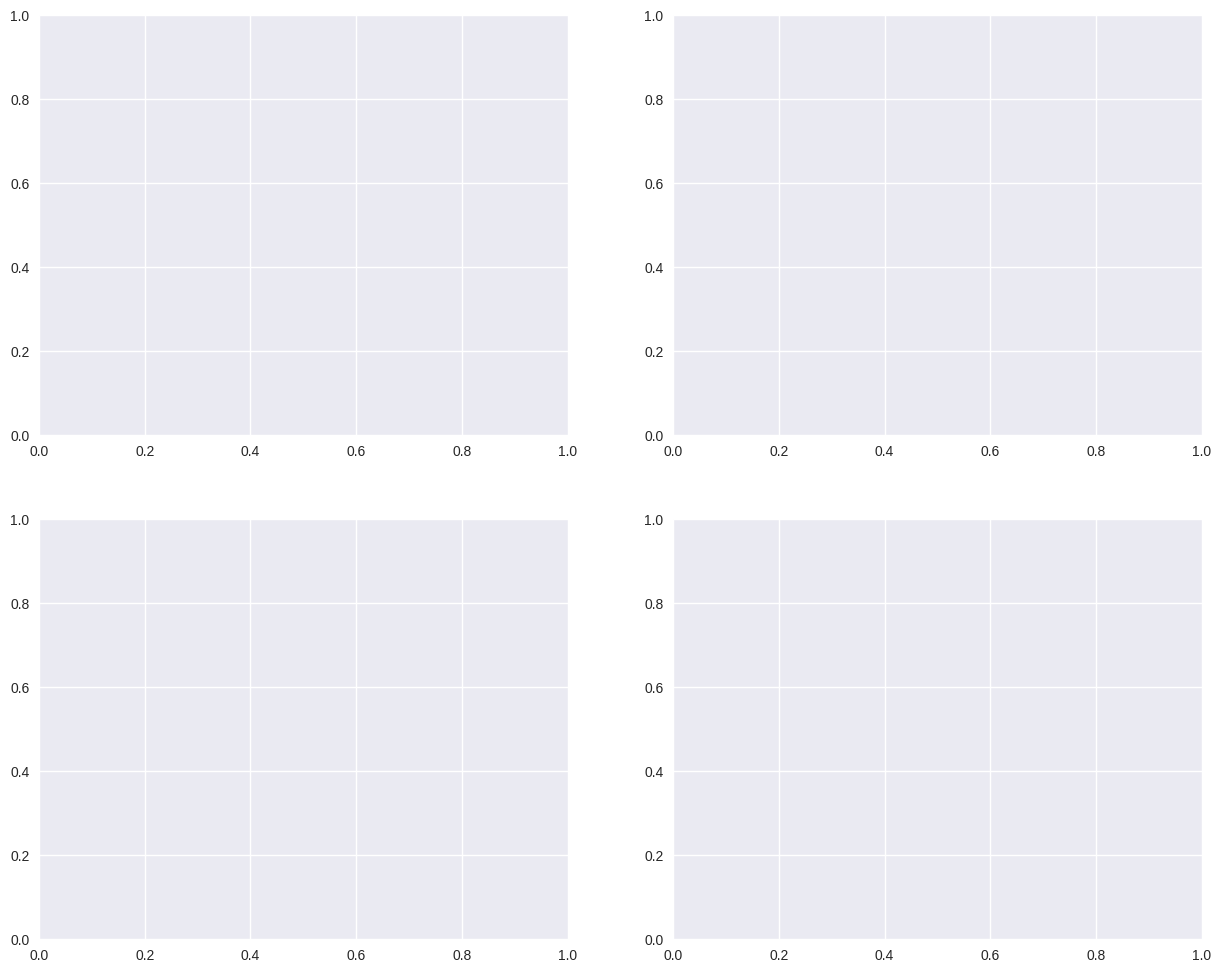

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# 1. Real vs Predito (Conjunto de Teste)
axes[0, 0].scatter(y_test, y_test_pred, alpha=0.6, s=30)
axes[0, 0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[0, 0].set_xlabel(f'{nome_target} Real')
axes[0, 0].set_ylabel(f'{nome_target} Predito')
axes[0, 0].set_title(f'Real vs Predito (Conjunto de Teste)\nR² = {test_r2:.4f}')
axes[0, 0].grid(True, alpha=0.3)

# 2. Gráfico de Resíduos (Conjunto de Teste)
residuals = y_test - y_test_pred
axes[0, 1].scatter(y_test_pred, residuals, alpha=0.6, s=30)
axes[0, 1].axhline(y=0, color='r', linestyle='--')
axes[0, 1].set_xlabel(f'{nome_target} Predito')
axes[0, 1].set_ylabel('Resíduos (Real - Predito)')
axes[0, 1].set_title('Gráfico de Resíduos (Conjunto de Teste)')
axes[0, 1].grid(True, alpha=0.3)

# 3. Importância das Features (Coeficientes)
feature_importance = pd.DataFrame({
    'Feature': X_train_scaled.columns,
    'Coefficient': model.coef_
})
feature_importance = feature_importance.sort_values('Coefficient', key=abs, ascending=False)

axes[1, 0].barh(feature_importance['Feature'], feature_importance['Coefficient'])
axes[1, 0].set_xlabel('Valor do Coeficiente')
axes[1, 0].set_title('Importância das Features (Coeficientes)')
axes[1, 0].grid(True, alpha=0.3)

# 4. Distribuição dos Resíduos
axes[1, 1].hist(residuals, bins=30, alpha=0.7, color='skyblue', edgecolor='black')
axes[1, 1].axvline(x=0, color='r', linestyle='--')
axes[1, 1].set_xlabel('Resíduos')
axes[1, 1].set_ylabel('Frequência')
axes[1, 1].set_title('Distribuição dos Resíduos')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("=== INTERPRETAÇÃO DAS VISUALIZAÇÕES ===")
print("1. Real vs Predito: Pontos próximos à linha vermelha indicam boas predições")
print("2. Gráfico de Resíduos: Pontos aleatoriamente espalhados ao redor do zero indicam bom ajuste do modelo")
print("3. Importância das Features: Mostra quais features têm a influência mais forte")
print("4. Distribuição dos Resíduos: Deve ser aproximadamente normal (forma de sino) ao redor do zero")

In [ ]:
# Insights adicionais: Análise das features
print("=== ANÁLISE DETALHADA DAS FEATURES ===")
print("\nFeatures mais importantes (por valor absoluto do coeficiente):")
for i, row in feature_importance.head(3).iterrows():
    coef_value = row['Coefficient']
    feature_name = row['Feature']
    direction = "aumenta" if coef_value > 0 else "diminui"
    print(f"• {feature_name}: {abs(coef_value):.4f} - {nome_target} {direction} quando esta feature aumenta")

print(f"\nResumo da Performance do Modelo:")
print(f"• O modelo explica {test_r2*100:.1f}% da variância em {nome_target}")
print(f"• Erro médio de predição: {test_mae:.2f} {unidade_target}")
print(f"• Modelo pode prever {nome_target} dentro de ±{test_rmse:.2f} {unidade_target} em média")

print(f"\n=== EXEMPLO DE PREDIÇÃO ===")
sample_features = X_test_scaled.iloc[0:1]
sample_actual = y_test.iloc[0]
sample_prediction = model.predict(sample_features)[0]

print(f"Features da amostra (padronizadas):")
for feature, value in zip(sample_features.columns, sample_features.iloc[0]):
    print(f"  {feature}: {value:.2f}")
print(f"\n{nome_target} real: {sample_actual:.2f} {unidade_target}")
print(f"{nome_target} predito: {sample_prediction:.2f} {unidade_target}")
print(f"Erro de predição: {abs(sample_actual - sample_prediction):.2f} {unidade_target}")

=== ANÁLISE DETALHADA DAS FEATURES ===

Features mais importantes (por valor absoluto do coeficiente):
• Latitude: 0.8969 - Preço diminui quando esta feature aumenta
• Longitude: 0.8698 - Preço diminui quando esta feature aumenta
• MedInc: 0.8544 - Preço aumenta quando esta feature aumenta

Resumo da Performance do Modelo:
• O modelo explica 57.6% da variância nos preços das casas
• Erro médio de predição: $0.53 centenas de milhares
• Modelo pode prever preços das casas dentro de ±$0.75 centenas de milhares em média

=== EXEMPLO DE PREDIÇÃO ===


AttributeError: 'numpy.ndarray' object has no attribute 'iloc'